For this notebook you will need to run 
```
mreyemove-fc-extract \
    --config SleepMReye/sleepmreye/designs/original_sleep.yml  \
    --bids-root BIDS_ROOT \
    --task sleep  \
    --tr=2.1  \
    --mrio sleepmreye  \
    --njobs 8 \
    --desc-add clean \
    --convolve \
    --output-dir SleepMReye/sleepmreye/results \
    --atlases schaefer500 
```

from the cli to extract the FC matrices we will use

In [3]:
from pathlib import Path

"""
Replace with your desired directories
"""

from utility import repo_root

FIG_DIR = Path("/Users/zach/2025_RA/matthias/final images/3_FC")
FIG_DIR.mkdir(exist_ok=True, parents=True)
BIDS_DIR = Path("/Users/zach/2025_RA/matthias/bids_sleepmreye")
CONFIG_DIR = Path(repo_root() / "sleepmreye" / "designs")

In [4]:
from mreyemove.analysis.glm.cli import construct_desc
from mreyemove.analysis.glm.config import GLMConfig
from SleepMReye.sleepmreye.sleep_mrio import SleepMRIO

mrio = SleepMRIO(
    bids_root=BIDS_DIR,
    tr=2.1,
    task="sleep",
    desc_add="clean",
    load_eog=False
)

config = GLMConfig.from_yaml(CONFIG_DIR / "original_sleep.yml")
desc_add = construct_desc(dataset=mrio, config=config)
desc_add = f"{desc_add}-{config.second_level.method}"
print(desc_add)


clean-original-sleep-incl-nrem3-flame


# Analysis Figures

[fetch_atlas_yeo_2011] Dataset found in /Users/zach/nilearn_data/yeo_2011


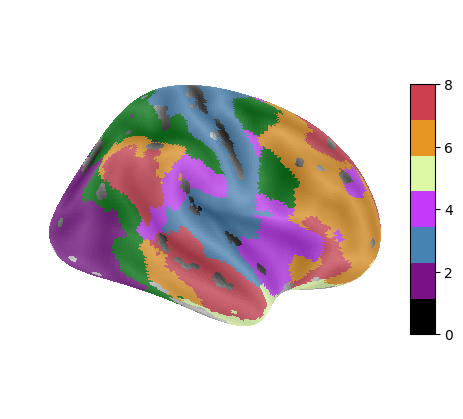

In [6]:
from nilearn.datasets import load_fsaverage_data
from nilearn import datasets, surface, plotting
import numpy as np
from matplotlib import pyplot as plt

fsaverage = datasets.load_fsaverage()
yeo = datasets.fetch_atlas_yeo_2011(n_networks=7)

# Project to surface with nearest-neighbor (no blurring)
labels_left = surface.vol_to_surf(
    yeo.maps, fsaverage['pial'].parts['left'], interpolation="nearest_most_frequent"
)
labels_right =  surface.vol_to_surf(
    yeo.maps, fsaverage['pial'].parts['right'], interpolation="nearest_most_frequent"
)

fsaverage_sulcal = load_fsaverage_data(data_type="sulcal")

labels_left[labels_left == 0] = np.nan
labels_right[labels_right == 0] = np.nan

labels =  {
    "left": labels_left,
    "right": labels_right,
}
hemi = "right"
fig = plotting.plot_surf_roi(
  fsaverage['inflated'].parts[hemi],
  roi_map=labels[hemi],
  hemi=hemi,
  view="lateral",
  cmap=yeo.lut,
  vmin=0,
  vmax=8,
  colorbar=True,
  bg_map=fsaverage_sulcal,
  bg_on_data=True,
  darkness=None,
)
plt.savefig(FIG_DIR / f"{hemi}_yeo.png", dpi=300)

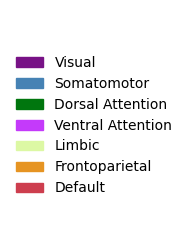

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

colors = yeo.lut["color"].tolist()[1:]  # skip background (0)
labels = ['Visual', 'Somatomotor', 'Dorsal Attention', 'Ventral Attention', 'Limbic', 'Frontoparietal', 'Default']

patches = [mpatches.Patch(color=c, label=l) for c, l in zip(colors, labels)]
fig, ax = plt.subplots(figsize=(2, 3))
ax.legend(handles=patches, loc="center", frameon=False)
ax.axis("off")
plt.savefig(FIG_DIR / 'colorbar.svg', dpi=300)
plt.show()


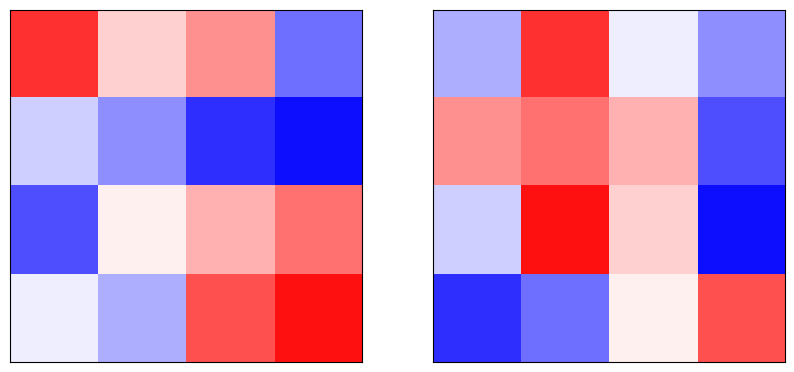

In [14]:
"""
Plot similar and different matrices for the analysis figure 
"""


from scipy.stats import rankdata
from matplotlib import pyplot as plt



def correlated_matrices(rho, size=4, value_range=(0, 1), seed=None):
    """
    Two `size` x `size` matrices with entries bounded in `value_range`
    and flattened Pearson/Spearman correlation near `rho`.

    Construction:
      1. Draw A, noise ~ N(0, 1), standardized.
      2. B = rho * A + sqrt(1 - rho^2) * noise.
      3. Map each matrix to uniform ranks in [0, 1], then scale to range.
         This bounds outputs exactly and preserves rank correlation.
    """
    if not -1 <= rho <= 1:
        raise ValueError("rho must be in [-1, 1].")
    low, high = value_range
    if high <= low:
        raise ValueError("value_range must be (low, high) with high > low.")

    rng = np.random.default_rng(seed)

    def standardize(x):
        return (x - x.mean()) / x.std()

    A = standardize(rng.standard_normal((size, size)))
    noise = standardize(rng.standard_normal((size, size)))
    B = rho * A + np.sqrt(1 - rho**2) * noise

    def to_range(x):
        # Rank-based mapping -> uniform on (0, 1), then rescale.
        # Using (rank - 0.5) / n puts values strictly inside (0, 1).
        n = x.size
        u = (rankdata(x, method="average").reshape(x.shape) - 0.5) / n
        return low + u * (high - low)

    return to_range(A), to_range(B)


# Plot different matrices
r = 0.0001
A, B = correlated_matrices(rho=r, size=4, seed=10, value_range=(-2, 2))

# f, axs = plt.subplots(2,1)
f, axs = plt.subplots(1,2, figsize=(10,5),subplot_kw={'xticks': [], 'yticks': []})

vmin = -2
vmax = 2
axs[0].imshow(A, cmap="bwr_r", vmin=vmin, vmax=vmax)
axs[1].imshow(B, cmap="bwr_r", vmin=vmin, vmax=vmax)
plt.savefig(FIG_DIR / 'toy_matrices.svg', dpi=300)
plt.show()


# Data Figure

In [15]:
from nilearn import datasets

atlas =  datasets.fetch_atlas_schaefer_2018(n_rois=500, yeo_networks=7)
schaefer_groups = {}
for label in atlas.labels:
    if label in ("Background", "???"):
        continue
    parts = label.split('_')
    if len(parts) >= 3:
        hemi, network, idx = parts[1], parts[2], parts[3]
        schaefer_groups[label] = network
    else:
        schaefer_groups[label] = None  # fallback
        
schaefer_order = ['Vis', 'Cont', 'DorsAttn', 'Default',  'SomMot', 'SalVentAttn',  'Limbic']
# print(set(schaefer_groups.values()))


[fetch_atlas_schaefer_2018] Dataset found in /Users/zach/nilearn_data/schaefer_2018


In [18]:
from typing import Iterable
from scipy.stats import false_discovery_control
import pandas as pd
import numpy as np 

def vec_upper(mat):
    upper_tri_indices = np.triu_indices_from(mat, k=1)
    return mat[upper_tri_indices], upper_tri_indices

def vecs_from_mats(subj_mats):
    """
    Extract upper triangle of edges (without diagonal) as a 1D vector for each matrix 
    and return as a matrix (n_subjs, n_edges)
    :param subj_mats: 
    :return: 
    """
    first = subj_mats[0]
    _, upper_tri_indices = vec_upper(first)
    V = np.vstack([m[upper_tri_indices] for m in subj_mats])  # (n_subj, n_edges)
    return V, upper_tri_indices

def mat_from_vec(v, n_rois):
    M = np.zeros((n_rois, n_rois), dtype=float)
    iu = np.triu_indices(n_rois, 1)
    M[iu] = v
    M[(iu[1], iu[0])] = v
    return M

def fc_paired_test(z_mats_A, z_mats_B, alpha=0.05, return_mats=True, alternative="greater", n_permutations=10000, seed=42):
    """
    Inputs:
      z_mats_A / z_mats_B: arrays of Fisher-z FC matrices with shape (n_subj, n_roi, n_roi)
    Returns:
      dict/DataFrame with edge-wise stats (+ optional matrix forms)
    """
    rng = np.random.default_rng(seed)
    A = np.asarray(z_mats_A)
    B = np.asarray(z_mats_B)
    assert A.shape == B.shape, f"Shape mismatch: {A.shape} vs {B.shape}"
    n_subj, n_roi, _ = A.shape

    VA, iu = vecs_from_mats(A)
    VB, _  = vecs_from_mats(B)
    D = VA - VB  # (n_subj, n_edges)
    mean_diff = np.nanmean(D, axis=0)
    
    
    # Sign-flipping null distribution
    n_edges = D.shape[1]
    count = np.zeros(n_edges, dtype=np.int32)
    
    chunk_size = 1
    for start in range(0, n_permutations, chunk_size):
        signs_chunk = rng.choice([-1, 1], size=(chunk_size, n_subj)).astype(np.float32)  # shape: (1, n_subj)
        chunk_means = np.dot(signs_chunk, D) / n_subj
        
        if alternative == "two-sided":
            count += (np.abs(chunk_means) >= np.abs(mean_diff)).sum(axis=0)
        elif alternative == "greater":
            count += (chunk_means >= mean_diff).sum(axis=0)
        else:  # less
            count += (chunk_means <= mean_diff).sum(axis=0)
    
    pvals = (count + 1) / (n_permutations + 1)


    # FDR 
    pvals_fdr = false_discovery_control(pvals)
    sig = pvals_fdr <= alpha

    # Effect size on good edges
    sd = np.nanstd(D, axis=0, ddof=1)
    dz = mean_diff / sd
    dz[sd == 0] = np.nan

    out = {
        "iu": iu,
        "mean_diff_vec": mean_diff,
        "pvals_vec": pvals,
        "pvals_fdr_vec": pvals_fdr,
        "significant_vec": sig,
        "cohens_dz_vec": dz,
        "n_subj": n_subj,
        "n_roi": n_roi,
    }

    if return_mats:
        out.update({
            "pvals_mat": mat_from_vec(pvals, n_roi),
            "pvals_fdr_mat": mat_from_vec(pvals_fdr, n_roi),
            "sig_mat": mat_from_vec(sig.astype(float), n_roi),
            "mean_diff_mat": mat_from_vec(mean_diff, n_roi),
            "cohens_dz_mat": mat_from_vec(dz, n_roi),
        })

    i_row, i_col = iu
    df = pd.DataFrame({
        "roi_i": i_row,
        "roi_j": i_col,
        "p": pvals,
        "p_fdr": pvals_fdr,
        "sig_fdr": sig,
        "mean_diff_z": mean_diff,
        "cohens_dz": dz,
    })
    out["table"] = df
    return out


def remove_labels(A, B, labels: Iterable, remove_starts_with: Iterable | None = None, remove_any: Iterable | None = None):
    A = np.asarray(A)      # (n_subj, n_roi, n_roi)
    B = np.asarray(B)
    assert A.shape == B.shape, f"Shape mismatch: {A.shape} vs {B.shape}"
    n_subj, n_roi, _ = A.shape
    
    # Boolean mask for GM (exclude WM)
    # Normalize inputs
    prefixes = tuple(s.lower() for s in (remove_starts_with or ()) if s)
    subs = tuple(s.lower() for s in (remove_any or ()) if s)

    # Lowercased copy for comparisons (keeps originals intact)
    labels_lower = [lbl.lower() for lbl in labels]
    
    # startswith can take a tuple of prefixes
    starts_mask = np.array(
        [lbl.startswith(prefixes) if prefixes else False for lbl in labels_lower],
        dtype=bool
    )
    # Any forbidden substring present?
    contains_mask = np.array(
        [any(s in lbl for s in subs) if subs else False for lbl in labels_lower],
        dtype=bool
    )
    keep_mask = ~(starts_mask | contains_mask)
    masked_labels = [lbl for lbl, keep in zip(labels, keep_mask) if keep]
    
    g = np.flatnonzero(keep_mask)     # indices of GM ROIs
    
    # Slice rows and columns using the GM index list
    A_clean = A[:, g, :][:, :, g]    # shape (n_subj, new_n_roi, new_n_roi)
    B_clean = B[:, g, :][:, :, g]
    
    print(f"A: {A_clean.shape}, B: {B_clean.shape}")
    
    return A_clean, B_clean, masked_labels


def process_matrices(results_dir, atlas):
    labels = atlas.labels[1:] # Ignore background
    
    with_eds = np.load(results_dir / f"schaefer500_conv-and-unconv_all_with_eds.npy")
    without_eds = np.load(results_dir / f"schaefer500_conv-and-unconv_all_without_eds.npy")
     
    return with_eds, without_eds, labels



In [19]:

results_dir = Path("/Users/zach/2025_RA/matthias/eyemove_and_sleep/SleepMReye/sleepmreye/results")
    
with_eds, without_eds, labels = process_matrices(results_dir, atlas)
assert with_eds.shape == without_eds.shape
_, n_roi, _ = with_eds.shape
assert len(labels) == n_roi, f"Labels {len(labels)} vs n_roi {n_roi}"

with_mean = np.mean(with_eds, axis=0)
without_mean = np.mean(without_eds, axis=0) 
ttest_res = fc_paired_test(without_eds, with_eds, return_mats=True, alternative="two-sided", n_permutations=10000) # Expect without to be greater

print(ttest_res["sig_mat"].astype(int).sum())
print("labels", len(labels))
print(with_mean.shape)
print("Background" in labels)
# 
# results =  {
#     "with_mean": with_mean,
#     "without_mean": without_mean,
#     "ttest_res": ttest_res
# }



27012
labels 500
(500, 500)
False


In [34]:

# Plot the correlation matrix
from scipy.stats import rankdata
from nilearn import plotting

import numpy as np
import matplotlib.pyplot as plt

def plot_grouped_matrix(
    mat,
    groups,
    group_order,
    roi_names=None,
    cmap="bwr",
    vlim=None,                 # None -> symmetric from visible data; scalar -> ±vlim; tuple -> (vmin, vmax)
    title=None,
    hide_diagonal=True,
    sig_mask=None,             # boolean NxN (True = keep)
    upper_triangle_masked=True,# top = sig-only, bottom = full
    ax=None,                   # <— NEW: draw into this axes if provided
    show_colorbar=False,        # <— NEW: you can add a shared CB outside
    rank=False,
    percentage=False,
):    
    N = mat.shape[0]
    # assert mat.shape[0] == mat.shape[1], "Matrix must be square"
    # assert len(groups) == N, f"groups length {len(groups)} != N {N}"
    if roi_names is None:
        roi_names = [f"ROI{i}" for i in range(N)]

    # order by group rank then roi name
    if len(groups) == N:
        grp_rank = {g: i for i, g in enumerate(group_order)}
        default_rank = len(group_order)
        order = sorted(range(N), key=lambda i: (grp_rank.get(groups[i], default_rank), roi_names[i]))
        groups_ord = [groups[i] for i in order]
        names_ord  = [roi_names[i] for i in order]
    else:
        order = range(N)
        groups_ord = ["" for _ in order]
        names_ord  = ["" for _ in order]

    mat_ord    = mat[np.ix_(order, order)].astype(float)

    sig_ord = None
    if sig_mask is not None:
        assert sig_mask.shape == mat.shape, "sig_mask must match mat shape"
        sig_ord = sig_mask[np.ix_(order, order)]
    

    # build display matrix
    M = mat_ord.copy()
    vmin, vmax = vlim
    if upper_triangle_masked and sig_ord is not None:
        
        M_plot = np.full_like(M, np.nan, dtype=float)
        iu = np.triu_indices_from(M, k=1)
        il = np.tril_indices_from(M, k=-1)
        sig_values =  np.where(sig_ord[iu], M[iu], np.nan) 
        M_plot[iu] = sig_values # upper: sig only
        # M_plot[iu] = np.where(sig_ord[iu] & (M[iu] < 0), M[iu], np.nan)  # upper: positive sig only
        M_plot[il] = M[il]                                  # lower: full
        
        # Figure out color thresholding
        if vmin is None and vmax is None:
            vmin = np.min(np.abs(sig_values[sig_values < 0]))
            vmax = np.min(np.abs(sig_values[sig_values > 0]))
        
        print(f"vmin = {vmin}")
        print(f"vmax = {vmax}")
        
        # Print proportion of positive and negative significant edges
        iu = np.triu_indices_from(sig_mask, k=1)
        sig_edges = sig_mask[iu]
        diff_vals = M[iu]
        
        sig_pos = (sig_edges & (diff_vals > 0)).sum()
        sig_neg = (sig_edges & (diff_vals < 0)).sum()
        total_edges = sig_edges.sum()
        
        print(f"Total significant edges: {total_edges} / {len(sig_edges)}")
        print(f"Positive (FC higher without gaze reg): {sig_pos} ({sig_pos/len(sig_edges)*100:.1f}%)")
        print(f"Negative (FC higher with gaze reg): {sig_neg} ({sig_neg/len(sig_edges)*100:.1f}%)")

    else:
        M_plot = M

    if hide_diagonal:
        np.fill_diagonal(M_plot, np.nan)
    M_masked = np.ma.masked_invalid(M_plot)

    # group bounds
    bounds, centers, labels_out = [], [], []
    for g in group_order:
        idx = [i for i, gg in enumerate(groups_ord) if gg == g]
        if not idx:
            continue
        s, e = min(idx), max(idx) + 1
        bounds.append((s, e, g))
        centers.append((s + e - 1) / 2)
        labels_out.append(g)

    # plotting
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(9, 8))
        created_fig = True
    else:
        fig = ax.figure

    ax.grid(False)

    # im = ax.imshow(M_masked, cmap=cmap, vmin=vmin, vmax=vmax, origin="upper",
    #                interpolation="nearest", aspect="equal")
    if rank:
        finite_mask = np.isfinite(M_plot)
        M_ranked = np.full_like(M_plot, np.nan)
        M_ranked[finite_mask] = rankdata(M_plot[finite_mask])
        M_masked = np.ma.masked_invalid(M_ranked)
        
    # if vmin is not None and vmax is not None:
    #     vlim = max(vmin, vmax)
    # vlim = None
    im = ax.imshow(M_masked, vmin=vmin, vmax=vmax, cmap=cmap, origin="upper",
                   interpolation="nearest", aspect="equal")
    
    # group grid lines and box
    for s, e, _ in bounds:
        ax.axhline(e - 0.5, color="k", lw=1)
        ax.axvline(e - 0.5, color="k", lw=1)
    ax.axhline(-0.5, color="k", lw=1); ax.axhline(N - 0.5, color="k", lw=1)
    ax.axvline(-0.5, color="k", lw=1); ax.axvline(N - 0.5, color="k", lw=1)

    # ticks per group
    ax.set_xticks(centers); ax.set_xticklabels(labels_out, rotation=45, ha="right")
    ax.set_yticks(centers); ax.set_yticklabels(labels_out)
    ax.tick_params(length=0)

    if title:
        ax.set_title(title)

    if show_colorbar:
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    if created_fig:
        plt.tight_layout()

    return fig, ax, im, order, names_ord
    

vmin = -0.01
vmax = 0.01
Total significant edges: 13506 / 124750
Positive (FC higher without gaze reg): 11173 (9.0%)
Negative (FC higher with gaze reg): 2333 (1.9%)


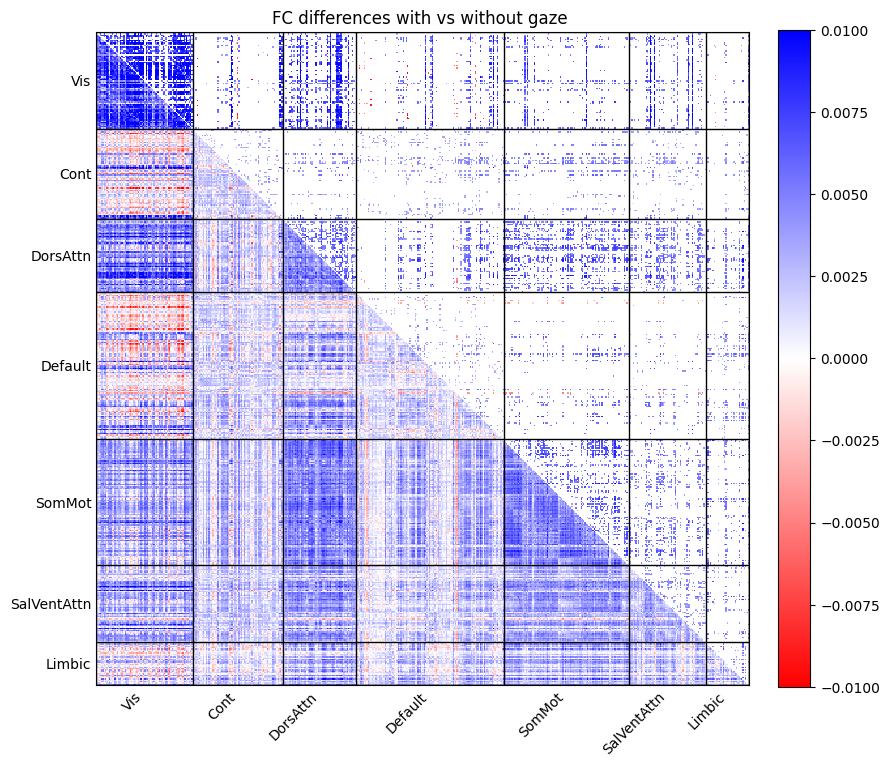

In [35]:
atlas_name = "schaefer500"

diff = np.tanh(with_mean) - np.tanh(without_mean)
perc_change_by_state = (diff / (np.tanh(without_mean) + np.identity(n=1, like=without_mean))) * 100
sig = ttest_res["sig_mat"]

vmax = np.nanmax(diff) 
vlim_shared = (-vmax, vmax)
cmap="bwr_r"
groups = [schaefer_groups[lbl] for lbl in labels]

_, _, im, order, names_ord = plot_grouped_matrix(
    -diff,
    groups=groups, 
    group_order=schaefer_order,
    roi_names=labels,
    hide_diagonal=True,
    cmap=cmap,
    vlim=(-0.01, 0.01),
    sig_mask=sig.astype(bool),
    upper_triangle_masked=True,
    show_colorbar=True,
    rank=False,
)
plt.title(f"FC differences with vs without gaze ")
plt.tight_layout()
plt.savefig(FIG_DIR / "FC_diff.svg", dpi=300)